<a href="https://colab.research.google.com/github/vidhyalakshmi130405-hub/THANYA/blob/main/PROJECT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHASE1: DATA UNDERSTANDING

   Organization_ID   Industry Company_Size  Employee_Count  AI_Tool  \
0                1  Education       Medium             819  ChatGPT   
1                2  Education       Medium            1382  Copilot   
2                3         IT        Small             447  ChatGPT   
3                4         IT        Small             385  ChatGPT   
4                5    Finance       Medium             571   Claude   

   Adoption_Year  Monthly_AI_Usage_Hours  Productivity_Gain  \
0           2025                      66              29.74   
1           2025                     167              11.55   
2           2023                     194              30.95   
3           2023                     110              11.31   
4           2023                      44              23.08   

   Satisfaction_Score  AI_Investment_USD  Cost_Savings_USD  
0                7.55               5770             33397  
1                6.41              46872            103675  
2          

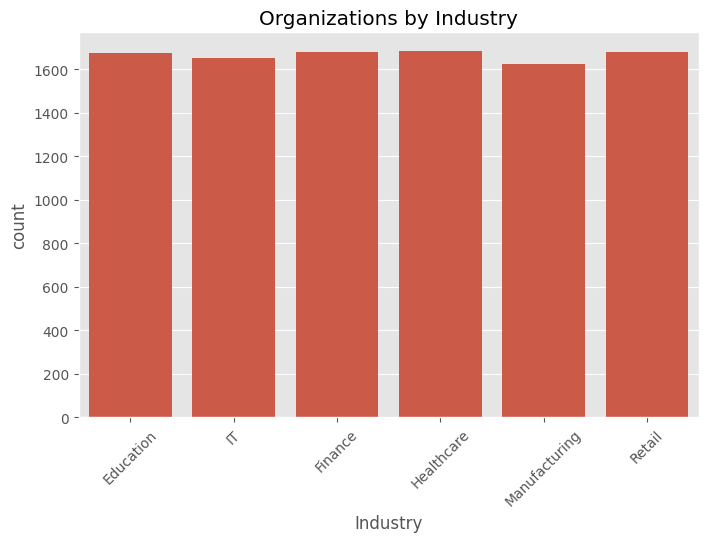

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

plt.style.use('ggplot')

df = pd.read_csv("/content/AI_Adoption_Trend_Dataset_10000 (1).csv")

print(df.head())

print(df.info())

print(df.isnull().sum())

print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print(df.describe())

print("Total Organizations:", len(df))

print(df['AI_Tool'].value_counts())

print(df['Industry'].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(x='Industry', data=df)
plt.title("Organizations by Industry")
plt.xticks(rotation=45)
plt.show()

PHASE 2:DESCRIPTIVE STATISTICAL ANALYSIS

Mean Productivity Gain
30.148459000000003
Median Productivity Gain
30.265
Standard Deviation
11.485870821934762
Quartiles
0.25    20.2875
0.50    30.2650
0.75    40.1000
Name: Productivity_Gain, dtype: float64
Percentiles
0.1    14.088
0.9    45.871
Name: Productivity_Gain, dtype: float64
Industry
Education        108.451940
Finance          111.739441
Healthcare       110.596439
IT               109.461911
Manufacturing    109.828923
Retail           109.594643
Name: Monthly_AI_Usage_Hours, dtype: float64
Company_Size
Large     3371
Medium    3368
Small     3261
Name: count, dtype: int64


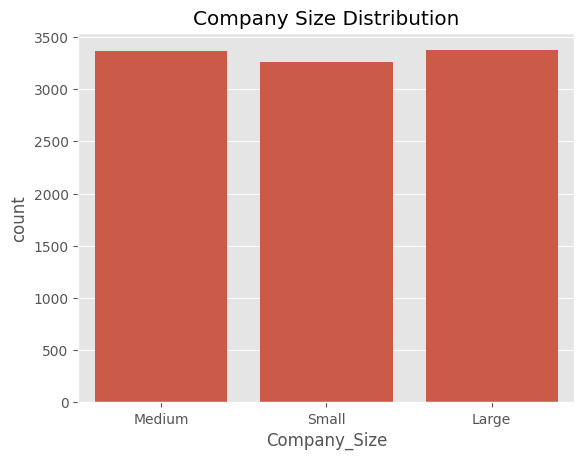

In [12]:
print("Mean Productivity Gain")
print(df['Productivity_Gain'].mean())

print("Median Productivity Gain")
print(df['Productivity_Gain'].median())

print("Standard Deviation")
print(df['Productivity_Gain'].std())

print("Quartiles")
print(df['Productivity_Gain'].quantile([0.25,0.50,0.75]))

print("Percentiles")
print(df['Productivity_Gain'].quantile([0.10,0.90]))
industry_usage = df.groupby('Industry')['Monthly_AI_Usage_Hours'].mean()

print(industry_usage)
print(df['Company_Size'].value_counts())

sns.countplot(x='Company_Size', data=df)
plt.title("Company Size Distribution")
plt.show()

PHASE 3:TREND INVESTIGATION

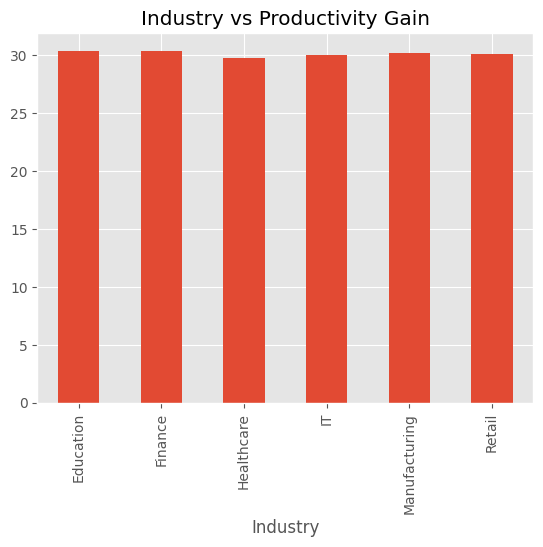

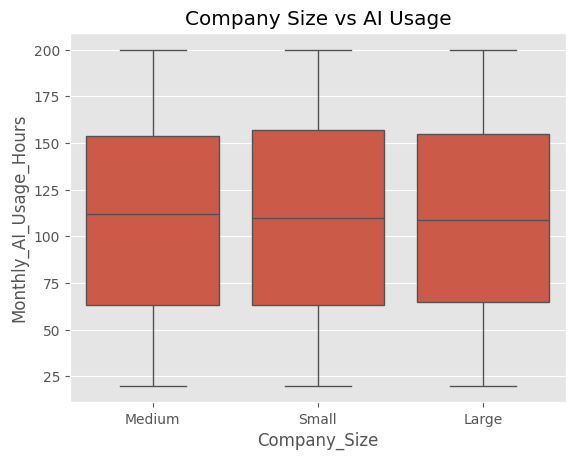

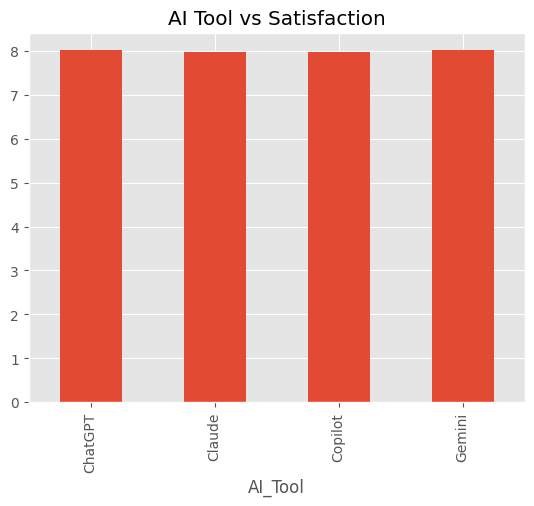

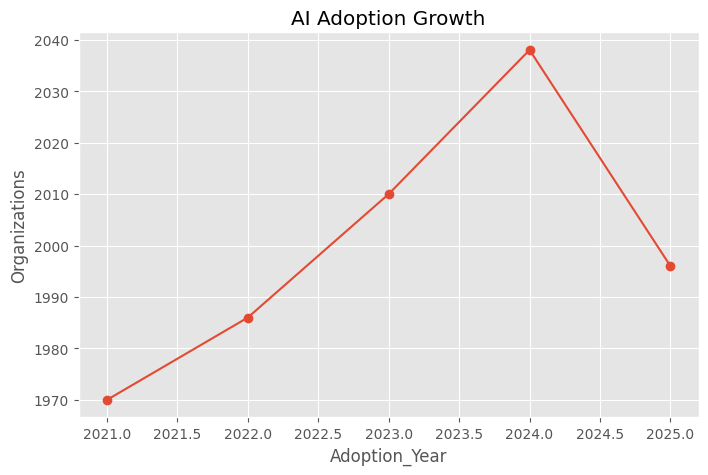

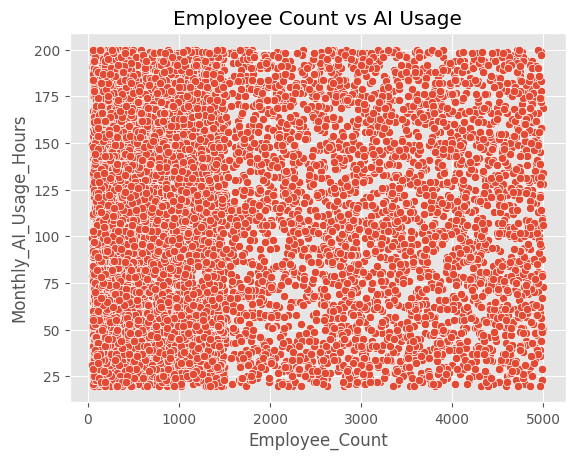

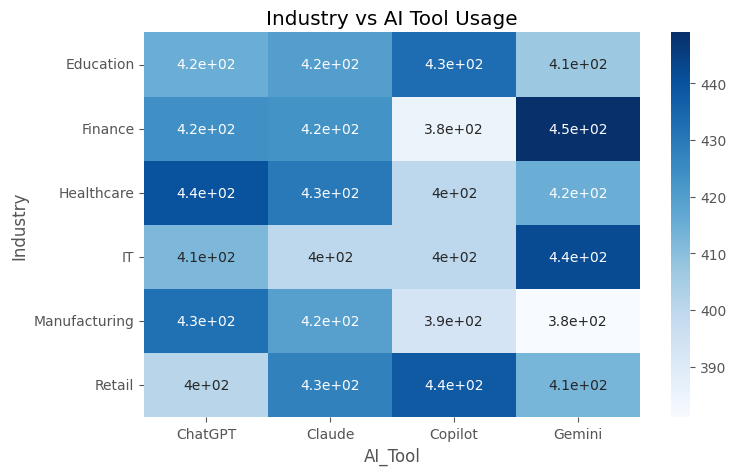

In [13]:
industry_productivity = df.groupby('Industry')['Productivity_Gain'].mean()

industry_productivity.plot(kind='bar')
plt.title("Industry vs Productivity Gain")
plt.show()
sns.boxplot(
    x='Company_Size',
    y='Monthly_AI_Usage_Hours',
    data=df
)

plt.title("Company Size vs AI Usage")
plt.show()
tool_sat = df.groupby('AI_Tool')['Satisfaction_Score'].mean()

tool_sat.plot(kind='bar')
plt.title("AI Tool vs Satisfaction")
plt.show()
growth = df.groupby('Adoption_Year').size()

growth.plot(
    kind='line',
    marker='o',
    figsize=(8,5)
)

plt.title("AI Adoption Growth")
plt.ylabel("Organizations")
plt.show()
sns.scatterplot(
    x='Employee_Count',
    y='Monthly_AI_Usage_Hours',
    data=df
)

plt.title("Employee Count vs AI Usage")
plt.show()
heatmap_data = pd.crosstab(
    df['Industry'],
    df['AI_Tool']
)

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='Blues'
)

plt.title("Industry vs AI Tool Usage")
plt.show()

PHASE 4:CORRELATION ANALYSIS

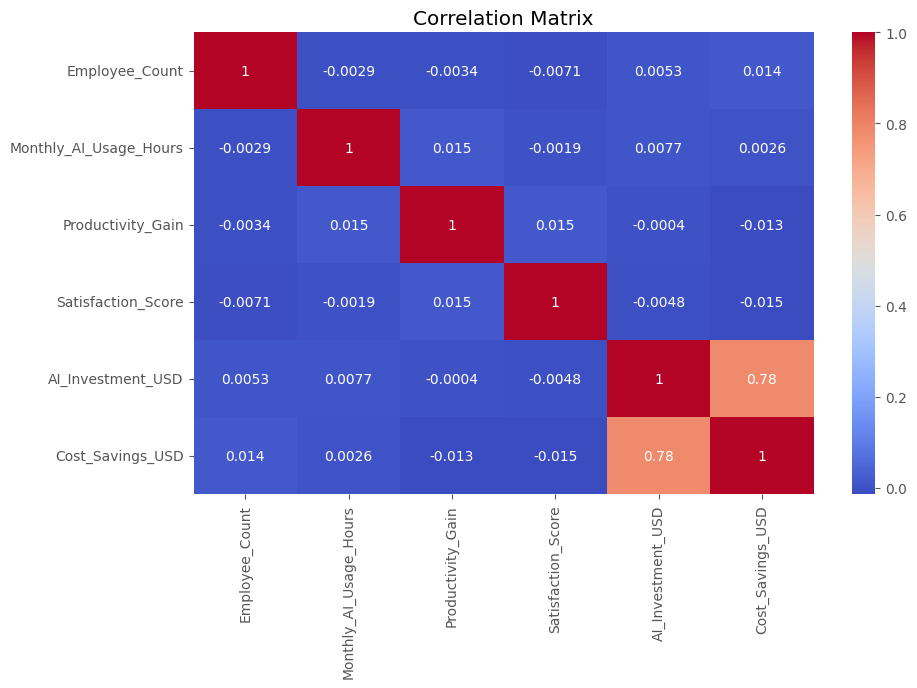

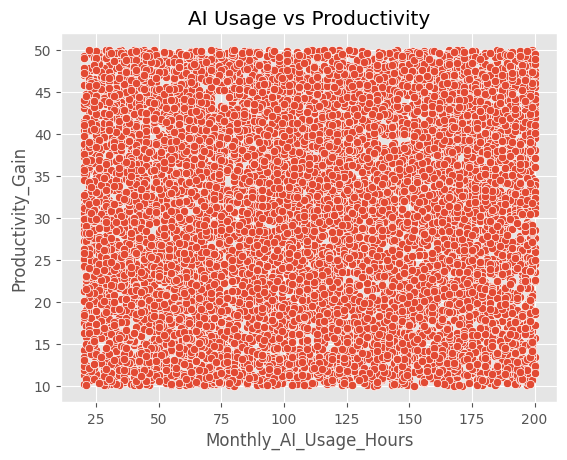

In [14]:
corr_columns = [
    'Employee_Count',
    'Monthly_AI_Usage_Hours',
    'Productivity_Gain',
    'Satisfaction_Score',
    'AI_Investment_USD',
    'Cost_Savings_USD'
]

corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()
sns.scatterplot(
    x='Monthly_AI_Usage_Hours',
    y='Productivity_Gain',
    data=df
)

plt.title("AI Usage vs Productivity")
plt.show()

PHASE 5:HYPOTHESIS TESTING

In [15]:
small = df[df['Company_Size']=="Small"]['Productivity_Gain']

medium = df[df['Company_Size']=="Medium"]['Productivity_Gain']

large = df[df['Company_Size']=="Large"]['Productivity_Gain']

f_stat,p_value = f_oneway(
    small,
    medium,
    large
)

print("F Statistic:",f_stat)
print("P Value:",p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Company size significantly affects AI adoption/productivity.")
else:
    print("Fail to Reject Null Hypothesis")

F Statistic: 0.47267294005568133
P Value: 0.6233478353628163
Fail to Reject Null Hypothesis


PHASE 6:ORGANIZATION SEGMENTATION

Segment
Early Adopter    3778
Slow Adopter     3692
AI Leader        2530
Name: count, dtype: int64


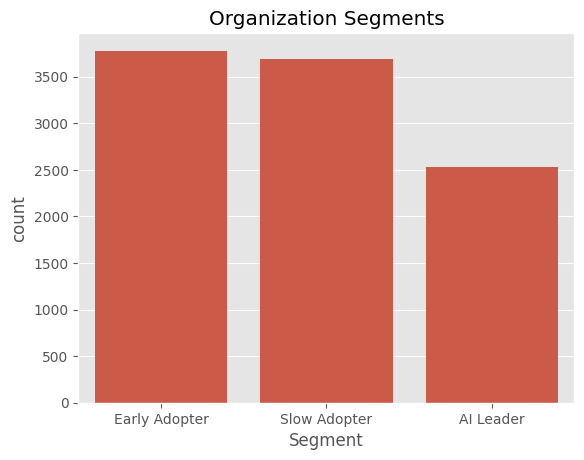

In [16]:
def classify(row):

    if row['Productivity_Gain'] >= 40:
        return "AI Leader"

    elif row['Productivity_Gain'] >= 25:
        return "Early Adopter"

    else:
        return "Slow Adopter"

df['Segment'] = df.apply(classify, axis=1)

print(df['Segment'].value_counts())
sns.countplot(
    x='Segment',
    data=df
)

plt.title("Organization Segments")
plt.show()

PHASE 7:BUSINESS INSIGHTS

In [17]:
print("Most Used AI Tool")
print(df['AI_Tool'].value_counts().idxmax())

print("\nLeading Industry")
print(
df.groupby('Industry')
['Productivity_Gain']
.mean()
.idxmax()
)

print("\nHighest Satisfaction Tool")
print(
df.groupby('AI_Tool')
['Satisfaction_Score']
.mean()
.idxmax()
)

print("\nHighest ROI Industry")
roi = (
df.groupby('Industry')['Cost_Savings_USD'].sum()
-
df.groupby('Industry')['AI_Investment_USD'].sum()
)

print(roi.idxmax())
df.to_csv(
    "Final_AI_Trend_Analysis_Output.csv",
    index=False
)

print("Analysis Completed Successfully")

Most Used AI Tool
ChatGPT

Leading Industry
Finance

Highest Satisfaction Tool
Gemini

Highest ROI Industry
Healthcare
Analysis Completed Successfully
